In [ ]:
# 既にインストールされていれば不要
!pip install stim

In [2]:
import stim
import numpy as np
import matplotlib.pyplot as plt

# グラフのスタイル設定
plt.rcParams['font.size'] = 12

print("Stim version:", stim.__version__)

Stim version: 1.15.0


In [3]:
def prepare_circuit_3qubit_X(p):
    """ 3量子ビットのビット反転符号の|0 L>状態を生成する回路を準備"""
    circuit = stim.Circuit()

    # --- Xエラーに対する耐性---
    # 1. 論理|0_L> = |000> を用意
    circuit.append("R", [0, 1, 2])
    # 2. Xエラー印加
    circuit.append("X_ERROR", [0, 1, 2], p)
    # 3. Z基底測定
    circuit.append("M", [0, 1, 2])

    return circuit

In [4]:
def prepare_circuit_3qubit_Z(p):
    """ 3量子ビットのビット反転符号の|+ L>状態を生成する回路を準備"""
    circuit = stim.Circuit()
    # 1. 論理|+_L> = (|000>+|111>)/sqrt(2) を用意(GHZ状態)
    circuit.append("R", [0, 1, 2])
    circuit.append("H", [0])
    circuit.append("CX", [0, 1, 0, 2]) # 0->1, 0->2
    # 2. Zエラー印加
    circuit.append("Z_ERROR", [0, 1, 2], p)
    # 3. XXX測定(論理パリティ測定)
    # すべてX基底(H->M)で測定
    circuit.append("H", [0, 1, 2])
    circuit.append("M", [0, 1, 2])
    return circuit

In [5]:
def get_3qubit_error_rate(p: float, noise_type: str, shots: int = 50000):
    if noise_type == "X":
        circuit = prepare_circuit_3qubit_X(p)
        # 実行
        results = circuit.compile_sampler().sample(shots)

        # 4. 多数決復号: 1 が2つ以上(反転多数)なら論理エラー
        # (例: 011 -> 多数決で1 -> 元が0なのでエラー)
        errors = np.sum(np.sum(results, axis=1) >= 2)

    elif noise_type == "Z":
        # --- Zエラーに対する耐性(訂正不可の確認) ---
        circuit = prepare_circuit_3qubit_Z(p)
        results = circuit.compile_sampler().sample(shots)

        # 4. エラー判定: XXXの測定値が-1 ならエラー
        # stimの結果は0(+1) または1(-1)．
        # 3 つの排他的論理和(奇数パリティ)が1 なら，全体の積は-1．
        # つまり，奇数個のqubitで位相が反転していれば論理エラー．
        parity = np.sum(results, axis=1) % 2
        errors = np.sum(parity == 1)

        # このような多数決復号は機能しない．
        # |+ L> = (|000>+|111>)/sqrt(2) ∝ |+++> + |+--> + |-+-> + |--+>であるため，
        # エラーのない状態についても，XXX測定の結果が-1 になる場合がある．
        # errors = np.sum(np.sum(results, axis=1) >= 2)

    return errors / shots

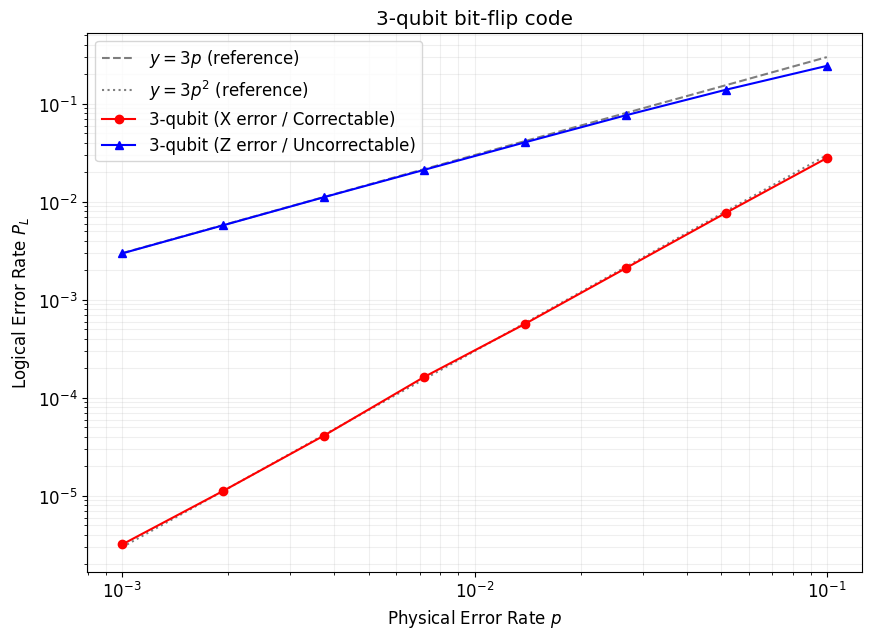

In [6]:
# パラメータ設定
probs = np.logspace(-3, -1, 8)
shots = 5_000_000

# データ収集
y_3bit_x = [get_3qubit_error_rate(p, "X", shots) for p in probs]
y_3bit_z = [get_3qubit_error_rate(p, "Z", shots) for p in probs]

# プロット
plt.figure(figsize=(10, 7))

# 参照線
# P_L = (3C1) p + O(p^2)
plt.loglog(probs, 3 * probs, 'k--', alpha=0.5, label="$y=3p$ (reference)")
# P_L = (3C2) p^2 (1 - p) + O(p^3)
plt.loglog(probs, 3 * probs**2, 'k:', alpha=0.5, label="$y=3p^2$ (reference)")

# 実験結果
plt.loglog(probs, y_3bit_x, 'o-', c="r" ,label="3-qubit (X error / Correctable)")
plt.loglog(probs, y_3bit_z, '^-', c="b", label="3-qubit (Z error / Uncorrectable)")
plt.xlabel("Physical Error Rate $p$")
plt.ylabel("Logical Error Rate $P_L$")
plt.title("3-qubit bit-flip code")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [7]:
def prepare_circuit_shor_X(p):
    """ 9量子ビットショア符号の|0 L>状態を生成する回路を準備"""
    circuit = stim.Circuit()
    q = list(range(9))

    # 論理|0_L> のエンコード
    circuit.append("R", q)
    circuit.append("H", [0])
    circuit.append("CX", [0, 3, 0, 6])
    circuit.append("H", [0, 3, 6])

    circuit.append("CX", [0, 1, 3, 4, 6, 7])
    circuit.append("CX", [0, 2, 3, 5, 6, 8])

    # Xエラー印加
    circuit.append("X_ERROR", q, p)

    # 論理情報を読み出すためZ基底で測定
    circuit.append("M", q)
    return circuit

In [8]:
def prepare_circuit_shor_Z(p):
    """ 9量子ビットShor符号の|+ L>状態を生成する回路を準備"""
    circuit = stim.Circuit()
    q = list(range(9))

    # 論理|+_L> のエンコード
    circuit.append("R", q)
    circuit.append("CX", [0, 3, 0, 6])
    circuit.append("H", [0, 3, 6])

    circuit.append("CX", [0, 1, 3, 4, 6, 7])
    circuit.append("CX", [0, 2, 3, 5, 6, 8])

    # Zエラー印加
    circuit.append("Z_ERROR", q, p)

    # 論理情報を読み出すためX基底で測定
    circuit.append("H", q)
    circuit.append("M", q)
    return circuit

In [9]:
def get_shor_error_rate(p: float, noise_type: str, shots: int = 50000):
    """
    ショア符号の論理エラー率を計算する．
    noise_type="X": 物理Xエラーに対する耐性を検証（論理|0>生成後，論理Xエラー率を測定）
    noise_type="Z": 物理Zエラーに対する耐性を検証（論理|+>生成後，論理Zエラー率を測定）
    """

    if noise_type == "X":
        circuit = prepare_circuit_shor_X(p)
        res = circuit.compile_sampler().sample(shots)

        # 各ブロック(3量子ビット)ごとに多数決をとる
        b1 = (np.sum(res[:, 0:3], axis=1) >= 2).astype(int)
        b2 = (np.sum(res[:, 3:6], axis=1) >= 2).astype(int)
        b3 = (np.sum(res[:, 6:9], axis=1) >= 2).astype(int)

        # 3ブロックの多数決結果(3ビット)のパリティをとる（奇数パリティならエラー）
        # 理由：式(9.24)(9.25)から|0_L>を計算すると，000 か 111 である3つのブロックのうち，
        # 111 は0個か2個になる．よって多数決をとって 000 か111 に訂正された3つのブロックの中に
        # 111 が奇数個含まれるものはエラーとなる
        parity = (b1 + b2 + b3) % 2
        return np.mean(parity == 1)

    if noise_type == "Z":
        circuit = prepare_circuit_shor_Z(p)
        res = circuit.compile_sampler().sample(shots)
        # 各ブロックで3ビットのパリティをとる
        b1 = np.sum(res[:, 0:3], axis=1) % 2
        b2 = np.sum(res[:, 3:6], axis=1) % 2
        b3 = np.sum(res[:, 6:9], axis=1) % 2
        # 3ブロックの多数決結果(3ビット)の多数決をとる
        majority_parity = (b1 + b2 + b3) >= 2
        return np.mean(majority_parity == 1)

    return 0.0

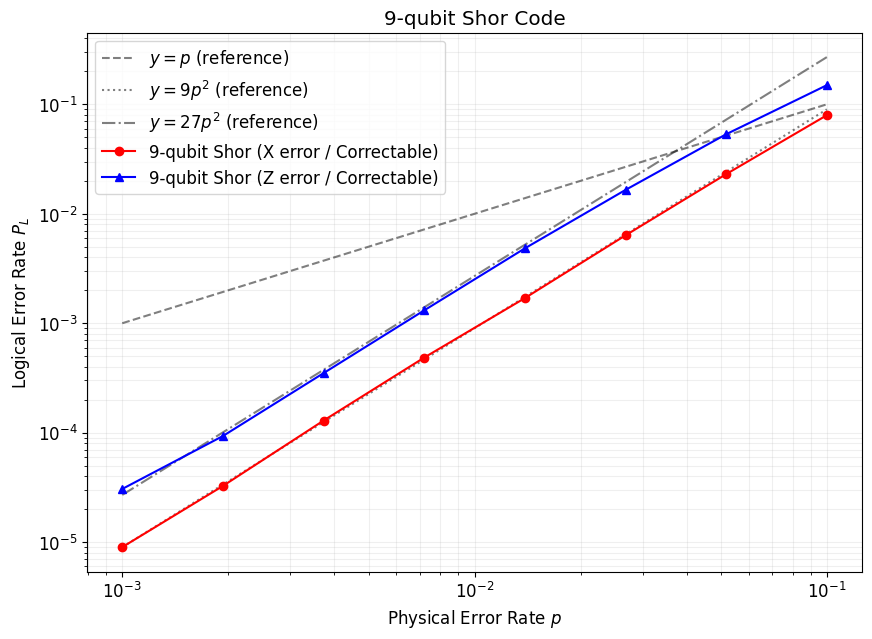

In [10]:
# パラメータ設定
probs = np.logspace(-3, -1, 8)
shots = 5_000_000

# データ収集
y_shor_x = [get_shor_error_rate(p, "X", shots) for p in probs]
y_shor_z = [get_shor_error_rate(p, "Z", shots) for p in probs]

# プロット
plt.figure(figsize=(10, 7))

# 参照線
plt.loglog(probs, probs, 'k--', alpha=0.5, label="$y=p$ (reference)")
plt.loglog(probs, 9*probs**2, 'k:', alpha=0.5, label="$y=9p^2$ (reference)")
plt.loglog(probs, 27*probs**2, 'k-.', alpha=0.5, label="$y=27p^2$ (reference)")

# 実験結果
plt.loglog(probs, y_shor_x, 'o-', c="r", label="9-qubit Shor (X error / Correctable)")
plt.loglog(probs, y_shor_z, '^-', c="b", label="9-qubit Shor (Z error / Correctable)")
plt.xlabel("Physical Error Rate $p$")
plt.ylabel("Logical Error Rate $P_L$")
plt.title("9-qubit Shor Code")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()